<h2 style='color:blue' align='center'>Small Image Classification Using Convolutional Neural Network (CNN)</h2>

In this notebook, we will classify small images cifar10 dataset from tensorflow keras datasets. There are total 10 classes as shown below. We will use CNN for classification

<img src="small_images.jpg" />

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [39]:
import pickle
import os
import numpy as np
from sklearn.model_selection import train_test_split

path = r"D:\Dataset\cifar-10-batches-py"

# Load data
with open(os.path.join(path, "data_batch_1"), "rb") as f:
    data = pickle.load(f, encoding="bytes")

X = data[b"data"]
y = np.array(data[b"labels"])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)



In [40]:
X_test.shape

(2000, 3072)

In [41]:
y_train.shape

(8000,)

In [10]:
y_train[:5]

array([4, 7, 2, 9, 3])

y_train is a 2D array, for our classification having 1D array is good enough. so we will convert this to now 1D array

In [11]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([4, 7, 2, 9, 3])

In [12]:
y_test = y_test.reshape(-1,)

In [13]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

Let's plot some images to see what they are 

In [14]:
def plot_sample(X, y, index):
    plt.figure(figsize = (15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

In [16]:
def plot_sample(X, y, index):
    img = X[index].reshape(3, 32, 32).transpose(1, 2, 0)  # (3072,) -> (32,32,3)
    plt.figure(figsize=(2, 2))
    plt.imshow(img)
    plt.axis("off")
    plt.title(classes[y[index]])
    plt.show()

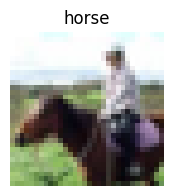

In [17]:
plot_sample(X_train, y_train, 1)

Normalize the images to a number from 0 to 1. Image has 3 channels (R,G,B) and each value in the channel can range from 0 to 255. Hence to normalize in 0-->1 range, we need to divide it by 255

In [18]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [20]:
ann = models.Sequential([
        layers.Flatten(input_shape=(32,32,3)),
        layers.Dense(3000, activation='relu'),
        layers.Dense(1000, activation='relu'),
        layers.Dense(10, activation='softmax')    
    ])

ann.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# CIFAR-10 data are stored as flattened vectors: (samples, 3072)
# Convert them to image tensors: (samples, 32, 32, 3)
X_train = X_train.reshape(-1, 32, 32, 3)
X_test = X_test.reshape(-1, 32, 32, 3)

# Train the ANN on 3-channel image data
ann.fit(X_train, y_train, epochs=5)

c:\Users\mdima\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.2560 - loss: 2.0347
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.3496 - loss: 1.8341
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.3736 - loss: 1.7598
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.4016 - loss: 1.6984
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.4236 - loss: 1.6512


In [21]:
from sklearn.metrics import confusion_matrix , classification_report
import numpy as np
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report: \n", classification_report(y_test, y_pred_classes))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.42      0.59      0.49       207
           1       0.47      0.62      0.53       213
           2       0.33      0.21      0.26       197
           3       0.32      0.32      0.32       199
           4       0.38      0.46      0.42       205
           5       0.35      0.27      0.30       177
           6       0.51      0.32      0.39       187
           7       0.49      0.54      0.51       200
           8       0.67      0.38      0.49       224
           9       0.43      0.57      0.49       191

    accuracy                           0.43      2000
   macro avg       0.44      0.43      0.42      2000
weighted avg       0.44      0.43      0.42      2000



In [22]:
cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

c:\Users\mdima\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [24]:
cnn.fit(X_train, y_train, epochs=10)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.2865 - loss: 1.9731
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.4215 - loss: 1.6341
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4712 - loss: 1.4971
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.4997 - loss: 1.4067
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5335 - loss: 1.3097
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5596 - loss: 1.2475
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5975 - loss: 1.1535
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6130 - loss: 1.0902
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6413 - loss: 1.0192
Epoch 10/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6662 - loss: 0.9470


In [32]:
cnn.evaluate(X_test,y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5450 - loss: 1.2985


[1.2984955310821533, 0.5450000166893005]

In [33]:
y_pred = cnn.predict(X_test)
y_pred[:5]

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


array([[2.88505962e-05, 6.32805968e-05, 1.13302795e-03, 4.88722138e-03,
        5.30666253e-03, 5.42706624e-03, 9.81918573e-01, 1.02110812e-03,
        1.74435816e-04, 3.97132972e-05],
       [1.18704287e-04, 1.84920698e-03, 5.40860579e-04, 1.24123486e-04,
        7.42363272e-06, 3.79284291e-04, 3.82142258e-04, 3.79249244e-03,
        4.03695973e-04, 9.92401958e-01],
       [2.97085699e-02, 3.30100447e-01, 9.92097333e-03, 1.53831458e-02,
        9.13563708e-05, 5.53373853e-03, 7.46430783e-03, 1.18264070e-04,
        1.16126254e-01, 4.85552967e-01],
       [3.05345803e-02, 6.33141324e-02, 6.11993717e-03, 7.18918163e-03,
        2.15387493e-02, 9.26545297e-04, 6.38560718e-03, 8.50609504e-03,
        6.07907593e-01, 2.47577608e-01],
       [3.61120375e-03, 2.52812897e-04, 2.01568037e-01, 4.12279256e-02,
        4.89189863e-01, 2.00606659e-02, 2.31211841e-01, 8.88778362e-03,
        3.81449517e-03, 1.75350680e-04]], dtype=float32)

In [34]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(6), np.int64(9), np.int64(9), np.int64(8), np.int64(4)]

In [35]:
y_test[:5]

array([6, 9, 1, 8, 2])

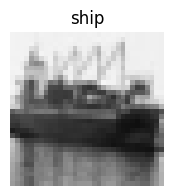

In [36]:
plot_sample(X_test, y_test,3)

In [37]:
classes[y_classes[3]]

'ship'

In [38]:
classes[y_classes[3]]

'ship'